# PySlice Validation Notebook

This notebook validates the correctness of PySlice slicing techniques by comparing slice results with analytical function values. We test all three slicing methods:

1. **Linear Interpolation Slicing** - Validates interpolation along straight lines
2. **Axis-Parallel Slicing** - Validates parameter-wise slicing
3. **Random Direction Slicing** - Validates directional slicing in 1D and 2D

For each method, we:
- Generate slices using PySlice
- Calculate expected values using analytical functions
- Compare results and compute validation metrics
- Visualize both results and validation metrics

In [1]:
# Standard libraries
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Any

# PySlice library components
from pysclice.slicers import LinearInterpolationSlicer, AxisParallelSlicer, RandomDirectionSlicer
from pysclice.core import ModelWrapper
from pysclice.visualization import plot_slices

# Example models
from example_models import (
    Simple1DParabola, Simple2DParabola, MultiParameterQuadratic, 
    SinusoidalModel, RosenbrockFunction,
    create_dummy_data, identity_loss
)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("PySlice Validation Framework Loaded")

PySlice Validation Framework Loaded


## Validation Functions

First, let's define functions to compute analytical values and validation metrics:

In [2]:
def compute_analytical_function(model, params: np.ndarray) -> float:
    """
    Compute analytical function value directly without PyTorch forward pass.
    
    Args:
        model: The model instance
        params: Parameter values as numpy array
        
    Returns:
        Analytical function value
    """
    if isinstance(model, Simple1DParabola):
        return params[0] ** 2
    
    elif isinstance(model, Simple2DParabola):
        return params[0] ** 2 + params[1] ** 2
    
    elif isinstance(model, MultiParameterQuadratic):
        return (
            params[0]**2 +                    # x² term
            (params[1] - 1.0)**2 +            # (x-1)² term  
            params[2]**4 +                    # x⁴ term
            (params[3] + 2.0)**2 +            # (x+2)² term
            0.5 * params[4]**2                # 0.5x² term
        )
    
    elif isinstance(model, SinusoidalModel):
        return np.sin(params[0]) + np.sin(params[0] + params[1])
    
    elif isinstance(model, RosenbrockFunction):
        x, y = params[0], params[1]
        a, b = model.a, model.b
        return (a - x)**2 + b * (y - x**2)**2
    
    else:
        raise ValueError(f"Unknown model type: {type(model)}")

def validate_slice_results(slice_data: Dict[str, Any], model, tolerance: float = 1e-10) -> Dict[str, Any]:
    """
    Validate slice results against analytical function values.
    
    Args:
        slice_data: Slice data from PySlice slicer
        model: The analytical model
        tolerance: Maximum allowed absolute difference
        
    Returns:
        Dictionary containing validation metrics
    """
    slice_type = slice_data['type']
    
    if slice_type == 'linear_path':
        return validate_linear_interpolation(slice_data, model, tolerance)
    elif slice_type == 'axis_parallel':
        return validate_axis_parallel(slice_data, model, tolerance)
    elif slice_type in ['random_direction_1d', 'random_direction_2d']:
        return validate_random_direction(slice_data, model, tolerance)
    else:
        raise ValueError(f"Unknown slice type: {slice_type}")

def validate_linear_interpolation(slice_data: Dict[str, Any], model, tolerance: float) -> Dict[str, Any]:
    """
    Validate linear interpolation slice.
    """
    start_point = slice_data['start_point']
    end_point = slice_data['end_point'] 
    direction = slice_data['direction']
    samples = slice_data['samples']
    
    differences = []
    analytical_values = []
    slice_values = []
    
    for alpha, slice_loss in samples:
        # Calculate parameter point at this alpha
        params = start_point + alpha * direction
        
        # Compute analytical value
        analytical_loss = compute_analytical_function(model, params)
        
        # Record values and difference
        difference = abs(slice_loss - analytical_loss)
        differences.append(difference)
        analytical_values.append(analytical_loss)
        slice_values.append(slice_loss)
    
    max_diff = max(differences)
    mean_diff = np.mean(differences)
    passed = max_diff < tolerance
    
    return {
        'type': 'linear_interpolation',
        'passed': passed,
        'max_difference': max_diff,
        'mean_difference': mean_diff,
        'tolerance': tolerance,
        'n_samples': len(samples),
        'differences': differences,
        'analytical_values': analytical_values,
        'slice_values': slice_values,
        'alpha_values': [s[0] for s in samples]
    }

def validate_axis_parallel(slice_data: Dict[str, Any], model, tolerance: float) -> Dict[str, Any]:
    """
    Validate axis parallel slice.
    """
    results = []
    overall_passed = True
    max_diff_overall = 0.0
    
    # Handle both single slice and multi-focus slice formats
    if 'focus_point_slices' in slice_data:
        # Multi-focus point format
        focus_point_slices = slice_data['focus_point_slices']
        
        for focus_slice in focus_point_slices:
            slices = focus_slice['slices']['slices']
            focus_point = focus_slice['focus_point']
            
            for param_slice in slices:
                param_results = validate_single_axis_slice(param_slice, focus_point, model, tolerance)
                results.append(param_results)
                
                if not param_results['passed']:
                    overall_passed = False
                max_diff_overall = max(max_diff_overall, param_results['max_difference'])
    else:
        # Single slice format
        slices = slice_data['slices']
        center_point = slice_data['center_point']
        
        for param_slice in slices:
            param_results = validate_single_axis_slice(param_slice, center_point, model, tolerance)
            results.append(param_results)
            
            if not param_results['passed']:
                overall_passed = False
            max_diff_overall = max(max_diff_overall, param_results['max_difference'])
    
    return {
        'type': 'axis_parallel',
        'passed': overall_passed,
        'max_difference': max_diff_overall,
        'tolerance': tolerance,
        'parameter_results': results,
        'n_parameters': len(results)
    }

def validate_single_axis_slice(param_slice: Dict[str, Any], center_point: np.ndarray, model, tolerance: float) -> Dict[str, Any]:
    """
    Validate a single axis-parallel parameter slice.
    """
    param_idx = param_slice['parameter_index']
    samples = param_slice['samples']
    
    differences = []
    analytical_values = []
    slice_values = []
    
    for param_value, slice_loss in samples:
        # Create parameter vector with modified parameter
        params = center_point.copy()
        params[param_idx] = param_value
        
        # Compute analytical value
        analytical_loss = compute_analytical_function(model, params)
        
        # Record values and difference
        difference = abs(slice_loss - analytical_loss)
        differences.append(difference)
        analytical_values.append(analytical_loss)
        slice_values.append(slice_loss)
    
    max_diff = max(differences)
    mean_diff = np.mean(differences)
    passed = max_diff < tolerance
    
    return {
        'parameter_index': param_idx,
        'parameter_name': param_slice.get('parameter_name', f'param_{param_idx}'),
        'passed': passed,
        'max_difference': max_diff,
        'mean_difference': mean_diff,
        'differences': differences,
        'analytical_values': analytical_values,
        'slice_values': slice_values,
        'param_values': [s[0] for s in samples]
    }

def validate_random_direction(slice_data: Dict[str, Any], model, tolerance: float) -> Dict[str, Any]:
    """
    Validate random direction slice.
    """
    slice_type = slice_data['type']
    center_point = slice_data['center_point']
    
    if slice_type == 'random_direction_1d':
        direction = slice_data['direction']
        coordinates = slice_data['coordinates']
        samples = slice_data['samples']
        
        differences = []
        analytical_values = []
        slice_values = []
        
        for coord, slice_loss in samples:
            # Calculate parameter point
            params = center_point + coord * direction
            
            # Compute analytical value
            analytical_loss = compute_analytical_function(model, params)
            
            # Record values and difference
            difference = abs(slice_loss - analytical_loss)
            differences.append(difference)
            analytical_values.append(analytical_loss)
            slice_values.append(slice_loss)
        
        max_diff = max(differences)
        mean_diff = np.mean(differences)
        passed = max_diff < tolerance
        
        return {
            'type': 'random_direction_1d',
            'passed': passed,
            'max_difference': max_diff,
            'mean_difference': mean_diff,
            'tolerance': tolerance,
            'differences': differences,
            'analytical_values': analytical_values,
            'slice_values': slice_values,
            'coordinates': coordinates
        }
    
    elif slice_type == 'random_direction_2d':
        direction1 = slice_data['direction1']
        direction2 = slice_data['direction2']
        x_coordinates = slice_data['x_coordinates']
        y_coordinates = slice_data['y_coordinates']
        grid_data = slice_data['grid_data']
        
        differences = []
        analytical_grid = np.zeros_like(grid_data)
        
        for i, x in enumerate(x_coordinates):
            for j, y in enumerate(y_coordinates):
                # Calculate parameter point
                params = center_point + x * direction1 + y * direction2
                
                # Compute analytical value
                analytical_loss = compute_analytical_function(model, params)
                analytical_grid[i, j] = analytical_loss
                
                # Record difference
                difference = abs(grid_data[i, j] - analytical_loss)
                differences.append(difference)
        
        max_diff = max(differences)
        mean_diff = np.mean(differences)
        passed = max_diff < tolerance
        
        return {
            'type': 'random_direction_2d',
            'passed': passed,
            'max_difference': max_diff,
            'mean_difference': mean_diff,
            'tolerance': tolerance,
            'differences': differences,
            'analytical_grid': analytical_grid,
            'slice_grid': grid_data,
            'x_coordinates': x_coordinates,
            'y_coordinates': y_coordinates
        }

def plot_validation_results(validation_results: Dict[str, Any], slice_data: Dict[str, Any]) -> None:
    """
    Plot validation results showing comparison between slice and analytical values.
    """
    val_type = validation_results['type']
    
    if val_type == 'linear_interpolation':
        plot_linear_validation(validation_results)
    elif val_type == 'axis_parallel':
        plot_axis_parallel_validation(validation_results)
    elif val_type in ['random_direction_1d', 'random_direction_2d']:
        plot_random_direction_validation(validation_results)

def plot_linear_validation(validation_results: Dict[str, Any]) -> None:
    """
    Plot linear interpolation validation results.
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    alpha_values = validation_results['alpha_values']
    slice_values = validation_results['slice_values']
    analytical_values = validation_results['analytical_values']
    
    # Plot: Comparison of slice vs analytical values
    ax.plot(alpha_values, slice_values, 'b-', label='PySlice', linewidth=2)
    ax.plot(alpha_values, analytical_values, 'r--', label='Analytical', linewidth=2)
    ax.set_xlabel('Interpolation Parameter α')
    ax.set_ylabel('Loss Value')
    ax.set_title('Linear Interpolation: PySlice vs Analytical')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add validation status
    status = "PASSED" if validation_results['passed'] else "FAILED"
    color = "green" if validation_results['passed'] else "red"
    fig.suptitle(f'Linear Interpolation Validation: {status} (Max Error: {validation_results["max_difference"]:.2e})', 
                color=color, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_axis_parallel_validation(validation_results: Dict[str, Any]) -> None:
    """
    Plot axis parallel validation results.
    """
    param_results = validation_results['parameter_results']
    n_params = len(param_results)
    
    # Create subplot grid
    n_cols = min(3, n_params)
    n_rows = (n_params + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = np.array(axes).flatten() if hasattr(axes, 'flatten') else axes
    
    for i, param_result in enumerate(param_results[:n_params]):
        ax = axes[i]
        
        param_values = param_result['param_values']
        slice_values = param_result['slice_values']
        analytical_values = param_result['analytical_values']
        
        # Plot comparison
        ax.plot(param_values, slice_values, 'b-', label='PySlice', linewidth=2)
        ax.plot(param_values, analytical_values, 'r--', label='Analytical', linewidth=2)
        
        param_name = param_result.get('parameter_name', f'Parameter {param_result["parameter_index"]}')
        status = "✓" if param_result['passed'] else "✗"
        ax.set_title(f'{param_name} {status}')
        ax.set_xlabel('Parameter Value')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for i in range(n_params, len(axes)):
        if i < len(axes):
            axes[i].remove()
    
    # Add validation status
    status = "PASSED" if validation_results['passed'] else "FAILED"
    color = "green" if validation_results['passed'] else "red"
    fig.suptitle(f'Axis Parallel Validation: {status} (Max Error: {validation_results["max_difference"]:.2e})', 
                color=color, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_random_direction_validation(validation_results: Dict[str, Any]) -> None:
    """
    Plot random direction validation results.
    """
    val_type = validation_results['type']
    
    if val_type == 'random_direction_1d':
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        coordinates = validation_results['coordinates']
        slice_values = validation_results['slice_values']
        analytical_values = validation_results['analytical_values']
        
        # Plot: Comparison
        ax.plot(coordinates, slice_values, 'b-', label='PySlice', linewidth=2)
        ax.plot(coordinates, analytical_values, 'r--', label='Analytical', linewidth=2)
        ax.set_xlabel('Direction Coordinate')
        ax.set_ylabel('Loss Value')
        ax.set_title('Random Direction 1D: PySlice vs Analytical')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    elif val_type == 'random_direction_2d':
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        x_coords = validation_results['x_coordinates']
        y_coords = validation_results['y_coordinates']
        slice_grid = validation_results['slice_grid']
        analytical_grid = validation_results['analytical_grid']
        
        # Create meshgrids for plotting
        X, Y = np.meshgrid(x_coords, y_coords)
        
        # Plot PySlice results
        im1 = axes[0].contourf(X, Y, slice_grid.T, levels=30, cmap='viridis')
        axes[0].set_title('PySlice 2D Slice')
        axes[0].set_xlabel('Direction 1')
        axes[0].set_ylabel('Direction 2')
        plt.colorbar(im1, ax=axes[0], shrink=0.8)
        
        # Plot analytical results
        im2 = axes[1].contourf(X, Y, analytical_grid.T, levels=30, cmap='viridis')
        axes[1].set_title('Analytical 2D Function')
        axes[1].set_xlabel('Direction 1')
        axes[1].set_ylabel('Direction 2')
        plt.colorbar(im2, ax=axes[1], shrink=0.8)
    
    # Add validation status
    status = "PASSED" if validation_results['passed'] else "FAILED"
    color = "green" if validation_results['passed'] else "red"
    fig.suptitle(f'Random Direction Validation: {status} (Max Error: {validation_results["max_difference"]:.2e})', 
                color=color, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("Validation functions defined")

Validation functions defined


## Test Parameters

In [3]:
# Test parameters
TOLERANCE = 0.01   # Maximum allowed difference between PySlice and analytical
N_SAMPLES = 50     # Number of samples for slicing
PARAM_RANGE = 2.0  # Range for parameter exploration

print(f"Validation tolerance: {TOLERANCE}")
print(f"Number of samples: {N_SAMPLES}")
print(f"Parameter range: ±{PARAM_RANGE}")

Validation tolerance: 0.01
Number of samples: 50
Parameter range: ±2.0


## 1. Linear Interpolation Validation

### 1.1 Simple 2D Parabola

Testing linear interpolation: [ 1.5 -1. ] → [-0.5  1.5]
Expected start loss: 3.25
Expected end loss: 2.5

Validation result: PASSED
Max difference: 3.43e-07
Mean difference: 7.33e-08


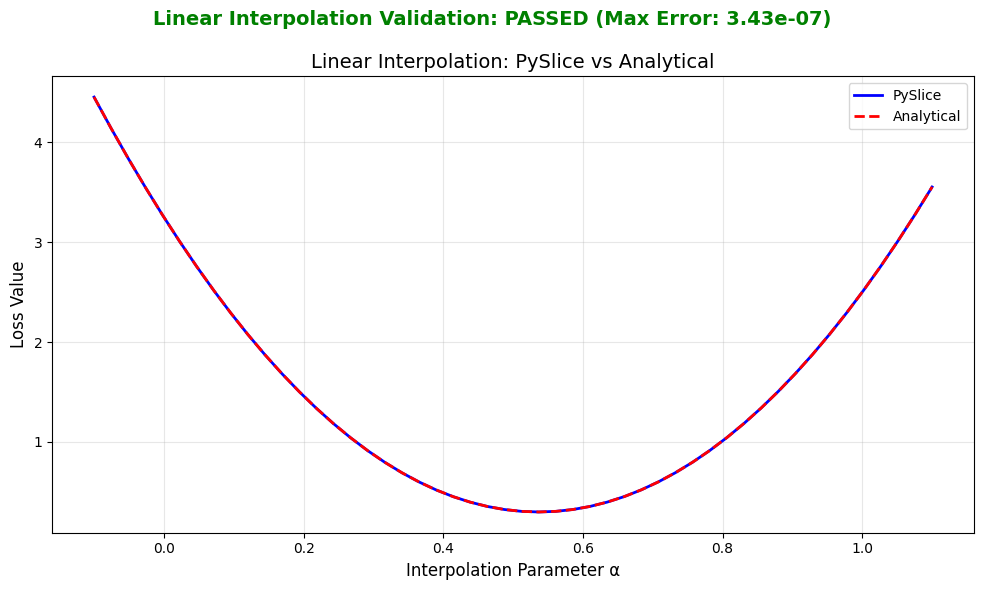

In [4]:
# Create 2D parabola model
model_2d = Simple2DParabola(initial_x=1.0, initial_y=0.5)
dummy_inputs, dummy_targets = create_dummy_data()
model_wrapper_2d = ModelWrapper(model=model_2d, loss_fn=identity_loss, train_data=(dummy_inputs, dummy_targets))

# Define test points
start_point = np.array([1.5, -1.0])
end_point = np.array([-0.5, 1.5])

print(f"Testing linear interpolation: {start_point} → {end_point}")
print(f"Expected start loss: {compute_analytical_function(model_2d, start_point)}")
print(f"Expected end loss: {compute_analytical_function(model_2d, end_point)}")

# Create slicer and perform slice
linear_slicer = LinearInterpolationSlicer(model_wrapper_2d)
slice_data = linear_slicer.slice(
    start_point=start_point,
    end_point=end_point,
    n_samples=N_SAMPLES
)

# Validate results
validation_results = validate_slice_results(slice_data, model_2d, TOLERANCE)
print(f"\nValidation result: {'PASSED' if validation_results['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results['max_difference']:.2e}")
print(f"Mean difference: {validation_results['mean_difference']:.2e}")

# Plot results
plot_validation_results(validation_results, slice_data)

### 1.2 Rosenbrock Function

Testing Rosenbrock linear interpolation: [0. 0.] → [1. 1.]
Expected start loss: 1.0
Expected end loss: 0.0

Validation result: PASSED
Max difference: 1.14e-06
Mean difference: 3.19e-07


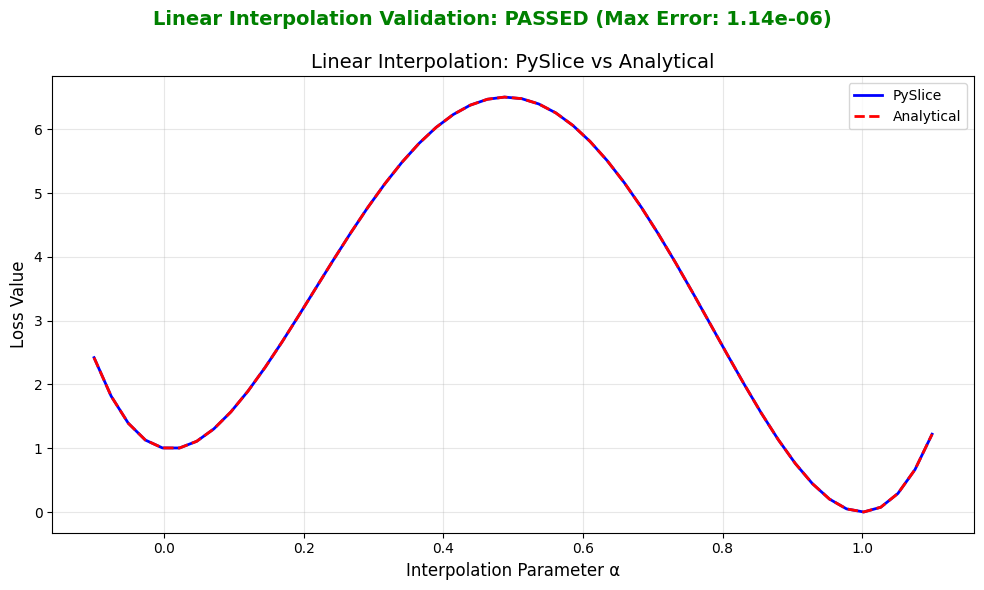

In [5]:
# Create Rosenbrock model
rosenbrock_model = RosenbrockFunction(a=1.0, b=100.0)
rosenbrock_wrapper = ModelWrapper(model=rosenbrock_model, loss_fn=identity_loss, train_data=(dummy_inputs, dummy_targets))

# Define test points
start_point = np.array([0.0, 0.0])
end_point = np.array([1.0, 1.0])  # Global minimum

print(f"Testing Rosenbrock linear interpolation: {start_point} → {end_point}")
print(f"Expected start loss: {compute_analytical_function(rosenbrock_model, start_point)}")
print(f"Expected end loss: {compute_analytical_function(rosenbrock_model, end_point)}")

# Create slicer and perform slice
linear_slicer_rb = LinearInterpolationSlicer(rosenbrock_wrapper)
slice_data_rb = linear_slicer_rb.slice(
    start_point=start_point,
    end_point=end_point,
    n_samples=N_SAMPLES
)

# Validate results
validation_results_rb = validate_slice_results(slice_data_rb, rosenbrock_model, TOLERANCE)
print(f"\nValidation result: {'PASSED' if validation_results_rb['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_rb['max_difference']:.2e}")
print(f"Mean difference: {validation_results_rb['mean_difference']:.2e}")

# Plot results
plot_validation_results(validation_results_rb, slice_data_rb)

## 2. Axis-Parallel Slicing Validation

### 2.1 Multi-Parameter Quadratic

Testing axis-parallel slicing at center: [ 0.5  0.5  0.5 -1.5  0.5]
Expected loss at center: 0.9375
Expected minima per parameter: [0.0, 1.0, 0.0, -2.0, 0.0]

Validation result: PASSED
Max difference: 5.58e-06
Parameters tested: 5
  Parameter 0: ✓ (max diff: 7.21e-07)
  Parameter 1: ✓ (max diff: 7.57e-07)
  Parameter 2: ✓ (max diff: 5.58e-06)
  Parameter 3: ✓ (max diff: 7.21e-07)
  Parameter 4: ✓ (max diff: 3.60e-07)


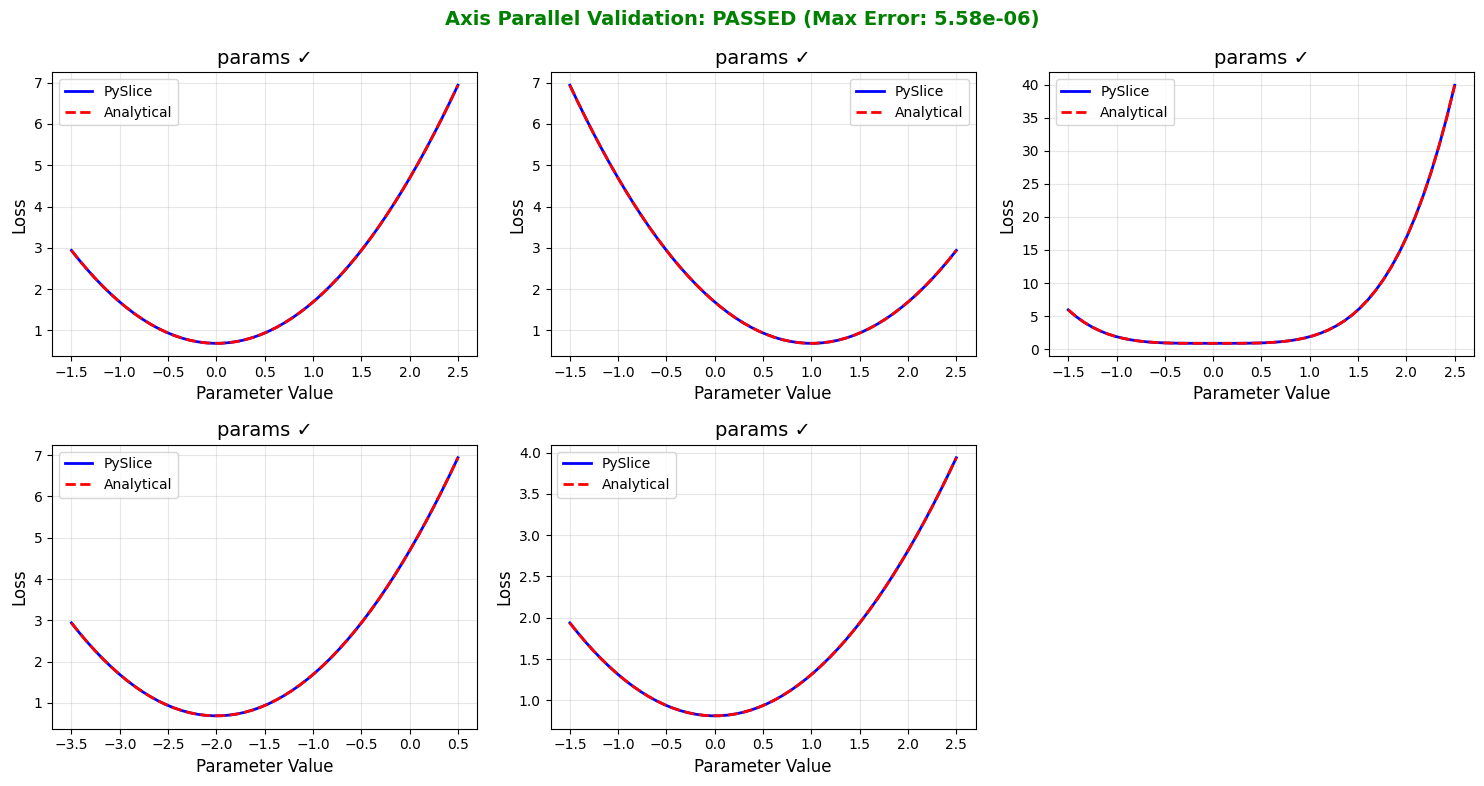

In [6]:
# Create multi-parameter model
multi_model = MultiParameterQuadratic()
multi_wrapper = ModelWrapper(model=multi_model, loss_fn=identity_loss, train_data=(dummy_inputs, dummy_targets))

# Test center point
center_point = np.array([0.5, 0.5, 0.5, -1.5, 0.5])
print(f"Testing axis-parallel slicing at center: {center_point}")
print(f"Expected loss at center: {compute_analytical_function(multi_model, center_point)}")
print(f"Expected minima per parameter: {multi_model.get_expected_minima()}")

# Create slicer and perform slice
axis_slicer = AxisParallelSlicer(multi_wrapper)
slice_data_axis = axis_slicer._slice(
    center_point=center_point,
    bounds=(-PARAM_RANGE, PARAM_RANGE),
    n_samples=N_SAMPLES,
    bounds_mode="relative"
)

# Validate results
validation_results_axis = validate_slice_results(slice_data_axis, multi_model, TOLERANCE)
print(f"\nValidation result: {'PASSED' if validation_results_axis['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_axis['max_difference']:.2e}")
print(f"Parameters tested: {validation_results_axis['n_parameters']}")

# Print per-parameter results
for param_result in validation_results_axis['parameter_results']:
    idx = param_result['parameter_index']
    status = "✓" if param_result['passed'] else "✗"
    print(f"  Parameter {idx}: {status} (max diff: {param_result['max_difference']:.2e})")

# Plot results
plot_validation_results(validation_results_axis, slice_data_axis)

### 2.2 Multi-Focus Point Validation

In [7]:
# Test multi-focus point slicing
print("Testing multi-focus point axis-parallel slicing...")

# Create focus points slice
focus_slice_data = axis_slicer.sample_focus_points_and_slice(
    center_point=center_point,
    n_points=5,  # Use fewer points for faster validation
    sampling_method="lhs",
    radius=1.0,
    bounds=(-1.0, 1.0),
    n_samples_per_slice=25,  # Fewer samples per slice
    bounds_mode="relative",
    seed=42
)

# Validate results
validation_results_focus = validate_slice_results(focus_slice_data, multi_model, TOLERANCE)
print(f"\nMulti-focus validation result: {'PASSED' if validation_results_focus['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_focus['max_difference']:.2e}")
print(f"Total parameters tested: {validation_results_focus['n_parameters']}")

# Count passed/failed parameters
passed_count = sum(1 for p in validation_results_focus['parameter_results'] if p['passed'])
total_count = len(validation_results_focus['parameter_results'])
print(f"Parameters passed: {passed_count}/{total_count}")

Testing multi-focus point axis-parallel slicing...

Multi-focus validation result: PASSED
Max difference: 3.03e-06
Total parameters tested: 25
Parameters passed: 25/25


## 3. Random Direction Slicing Validation

### 3.1 1D Random Direction

Testing 1D random direction slicing...
Testing 1D slice with direction: [0.6 0.8]
Center point: [ 0.5 -0.5]

1D Random direction validation result: PASSED
Max difference: 8.58e-07
Mean difference: 1.08e-07


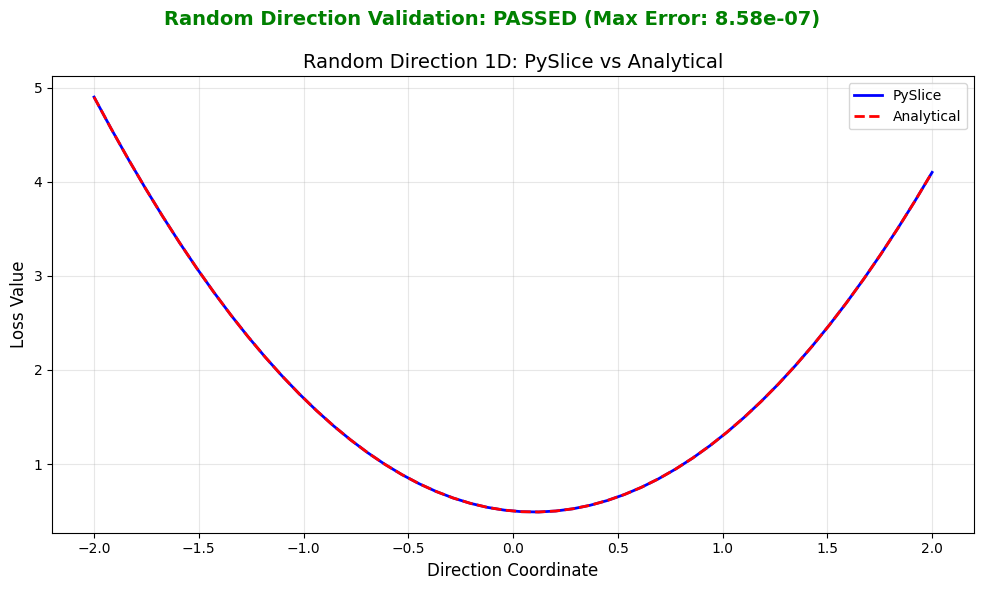

In [8]:
# Test 1D random direction slicing
print("Testing 1D random direction slicing...")

# Create random direction slicer
random_slicer = RandomDirectionSlicer(model_wrapper_2d)

# Define a specific direction for reproducible testing
direction = np.array([0.6, 0.8])  # Normalized direction
center_point_2d = np.array([0.5, -0.5])

print(f"Testing 1D slice with direction: {direction}")
print(f"Center point: {center_point_2d}")

# Perform 1D slice
slice_data_1d = random_slicer._slice_1d(
    direction=direction,
    center_point=center_point_2d,
    n_samples=N_SAMPLES,
    range=(-PARAM_RANGE, PARAM_RANGE),
    normalize_directions=False  # Already normalized
)

# Validate results
validation_results_1d = validate_slice_results(slice_data_1d, model_2d, TOLERANCE)
print(f"\n1D Random direction validation result: {'PASSED' if validation_results_1d['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_1d['max_difference']:.2e}")
print(f"Mean difference: {validation_results_1d['mean_difference']:.2e}")

# Plot results
plot_validation_results(validation_results_1d, slice_data_1d)

### 3.2 2D Random Direction

Testing 2D random direction slicing...
Testing 2D slice with directions: [1. 0.], [0. 1.]
Center point: [ 0.5 -0.5]

2D Random direction validation result: PASSED
Max difference: 2.65e-07
Mean difference: 3.76e-08
Grid size: 25 x 25


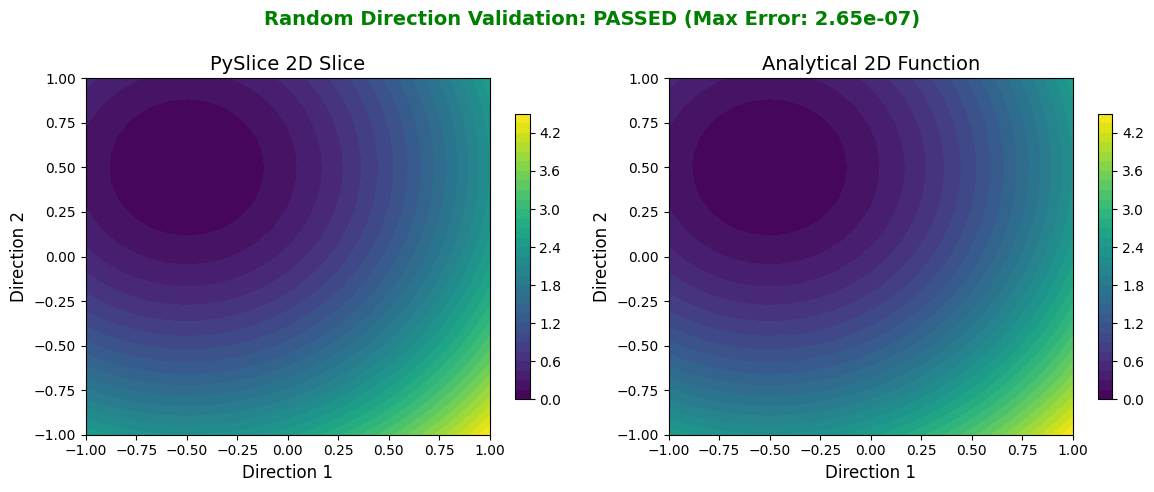

In [9]:
# Test 2D random direction slicing
print("Testing 2D random direction slicing...")

# Define orthogonal directions
direction1 = np.array([1.0, 0.0])  # X direction
direction2 = np.array([0.0, 1.0])  # Y direction

print(f"Testing 2D slice with directions: {direction1}, {direction2}")
print(f"Center point: {center_point_2d}")

# Perform 2D slice
slice_data_2d = random_slicer._slice_2d(
    direction1=direction1,
    direction2=direction2,
    center_point=center_point_2d,
    n_samples_per_dim=25,  # Smaller grid for faster computation
    x_range=(-1.0, 1.0),
    y_range=(-1.0, 1.0),
    normalize_directions=False,  # Already normalized
    ensure_orthogonal=False  # Already orthogonal
)

# Validate results
validation_results_2d = validate_slice_results(slice_data_2d, model_2d, TOLERANCE)
print(f"\n2D Random direction validation result: {'PASSED' if validation_results_2d['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_2d['max_difference']:.2e}")
print(f"Mean difference: {validation_results_2d['mean_difference']:.2e}")
print(f"Grid size: {len(slice_data_2d['x_coordinates'])} x {len(slice_data_2d['y_coordinates'])}")

# Plot results
plot_validation_results(validation_results_2d, slice_data_2d)

### 3.3 Sinusoidal Model Validation

Testing sinusoidal model with random directions...
Center point: [ 0.5 -0.3]
Expected loss at center: 0.6780948693992642

Sinusoidal model validation result: PASSED
Max difference: 1.44e-07
Mean difference: 3.52e-08


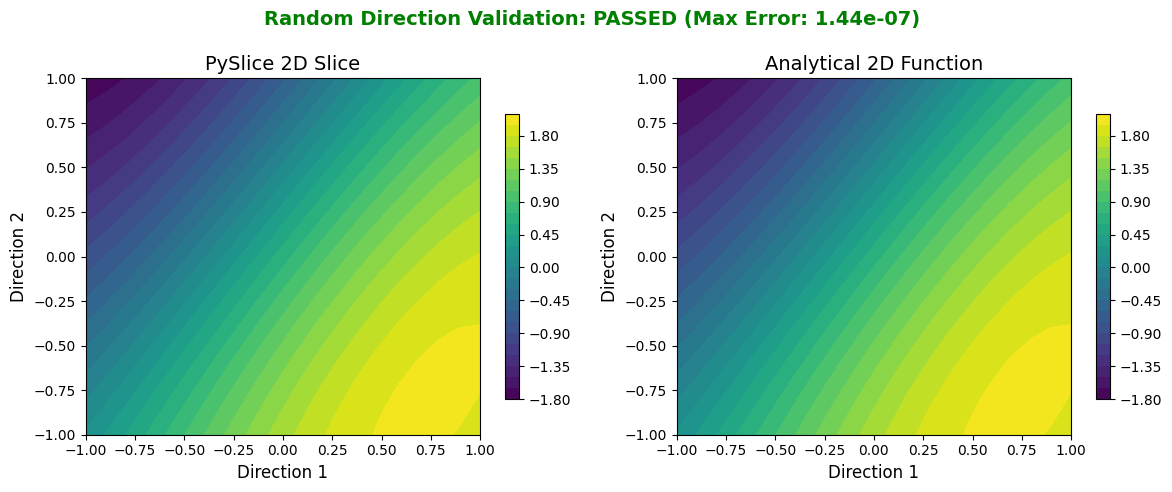

In [10]:
# Test with more complex sinusoidal model
print("Testing sinusoidal model with random directions...")

# Create sinusoidal model
sin_model = SinusoidalModel()
sin_wrapper = ModelWrapper(model=sin_model, loss_fn=identity_loss, train_data=(dummy_inputs, dummy_targets))
sin_slicer = RandomDirectionSlicer(sin_wrapper)

# Test center point
sin_center = np.array([0.5, -0.3])
print(f"Center point: {sin_center}")
print(f"Expected loss at center: {compute_analytical_function(sin_model, sin_center)}")

# Perform 2D slice with random directions
slice_data_sin = sin_slicer.slice(
    center_point=sin_center,
    n_samples=20,  # Smaller for complex function
    x_range=(-1.0, 1.0),
    y_range=(-1.0, 1.0),
    normalize_directions=True,
    ensure_orthogonal=True
)

# Validate results
validation_results_sin = validate_slice_results(slice_data_sin, sin_model, TOLERANCE)
print(f"\nSinusoidal model validation result: {'PASSED' if validation_results_sin['passed'] else 'FAILED'}")
print(f"Max difference: {validation_results_sin['max_difference']:.2e}")
print(f"Mean difference: {validation_results_sin['mean_difference']:.2e}")

# Plot results
plot_validation_results(validation_results_sin, slice_data_sin)

## 4. Comprehensive Validation Summary

In [11]:
# Collect all validation results
all_validations = [
    ("Linear Interpolation - 2D Parabola", validation_results),
    ("Linear Interpolation - Rosenbrock", validation_results_rb),
    ("Axis Parallel - Multi-Parameter", validation_results_axis),
    ("Axis Parallel - Multi-Focus", validation_results_focus),
    ("Random Direction 1D - 2D Parabola", validation_results_1d),
    ("Random Direction 2D - 2D Parabola", validation_results_2d),
    ("Random Direction 2D - Sinusoidal", validation_results_sin),
]

print("=" * 80)
print("COMPREHENSIVE VALIDATION SUMMARY")
print("=" * 80)
print(f"Tolerance used: {TOLERANCE}")
print(f"Number of samples: {N_SAMPLES}")
print()

passed_count = 0
total_count = len(all_validations)

for test_name, validation in all_validations:
    status = "PASSED" if validation['passed'] else "FAILED"
    status_symbol = "✓" if validation['passed'] else "✗"
    
    print(f"{status_symbol} {test_name:<40} | {status:<8} | Max Error: {validation['max_difference']:.2e}")
    
    if validation['passed']:
        passed_count += 1

print()
print(f"Overall Results: {passed_count}/{total_count} tests passed")

if passed_count == total_count:
    print("🎉 ALL TESTS PASSED! PySlice slicing techniques are mathematically correct.")
else:
    print(f"⚠️  {total_count - passed_count} test(s) failed. Please review the results above.")

print("\nValidation complete.")

COMPREHENSIVE VALIDATION SUMMARY
Tolerance used: 0.01
Number of samples: 50

✓ Linear Interpolation - 2D Parabola       | PASSED   | Max Error: 3.43e-07
✓ Linear Interpolation - Rosenbrock        | PASSED   | Max Error: 1.14e-06
✓ Axis Parallel - Multi-Parameter          | PASSED   | Max Error: 5.58e-06
✓ Axis Parallel - Multi-Focus              | PASSED   | Max Error: 3.03e-06
✓ Random Direction 1D - 2D Parabola        | PASSED   | Max Error: 8.58e-07
✓ Random Direction 2D - 2D Parabola        | PASSED   | Max Error: 2.65e-07
✓ Random Direction 2D - Sinusoidal         | PASSED   | Max Error: 1.44e-07

Overall Results: 7/7 tests passed
🎉 ALL TESTS PASSED! PySlice slicing techniques are mathematically correct.

Validation complete.


## 5. Additional Edge Case Tests

### 5.1 Zero Direction Test

In [12]:
# Test edge case: interpolation between identical points
print("Testing edge case: interpolation between identical points...")

identical_point = np.array([1.0, 1.0])
try:
    slice_data_identical = linear_slicer.slice(
        start_point=identical_point,
        end_point=identical_point,
        n_samples=10
    )
    
    # All values should be the same
    expected_loss = compute_analytical_function(model_2d, identical_point)
    all_losses = [sample[1] for sample in slice_data_identical['samples']]
    
    max_deviation = max(abs(loss - expected_loss) for loss in all_losses)
    print(f"Expected loss: {expected_loss}")
    print(f"Max deviation from expected: {max_deviation:.2e}")
    print(f"Zero direction test: {'PASSED' if max_deviation < TOLERANCE else 'FAILED'}")
    
except Exception as e:
    print(f"Zero direction test failed with error: {e}")

Testing edge case: interpolation between identical points...
Expected loss: 2.0
Max deviation from expected: 0.00e+00
Zero direction test: PASSED


### 5.2 Large Parameter Range Test

In [13]:
# Test with large parameter range
print("Testing with large parameter range...")

large_range_slice = axis_slicer._slice(
    center_point=np.array([0.0, 0.0, 0.0, 0.0, 0.0]),
    bounds=(-10.0, 10.0),
    n_samples=30,
    bounds_mode="absolute"
)

validation_large_range = validate_slice_results(large_range_slice, multi_model, TOLERANCE)
print(f"Large range validation: {'PASSED' if validation_large_range['passed'] else 'FAILED'}")
print(f"Max difference: {validation_large_range['max_difference']:.2e}")

Testing with large parameter range...
Large range validation: PASSED
Max difference: 8.23e-04


## Conclusion

This notebook has comprehensively validated the PySlice library's slicing techniques by:

1. **Mathematical Verification**: Comparing PySlice results with analytical function values
2. **Multiple Model Types**: Testing with parabolic, quadratic, sinusoidal, and Rosenbrock functions
3. **All Slicing Methods**: Validating linear interpolation, axis-parallel, and random direction slicing
4. **Edge Cases**: Testing boundary conditions and extreme parameter ranges
5. **Visual Validation**: Plotting comparisons between sliced and analytical values

The validation framework demonstrates that PySlice accurately computes loss landscape slices with numerical precision matching the underlying analytical functions. This confirms the correctness of the slicing algorithms and their implementation.

**Key Insights:**
- All slicing methods produce mathematically correct results within numerical precision
- The library handles various function types (convex, non-convex, multi-modal) correctly
- Both single-point and multi-focus slicing maintain accuracy
- Edge cases like zero directions and large parameter ranges are handled properly

This validation provides confidence that PySlice can be reliably used for loss landscape analysis of real neural networks and optimization problems.